In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import config
import rioxarray
newer_year = 2021
older_year = 2019
def plot_nc_urban_core(
    raster_da, 
    counties_shp_path, 
    title="Radiance Plot", 
    vmin=None, s
    vmax=None, 
    cmap='magma',
    buffer_deg=0.05,
    outline_color='white'
):
    """
    Clips and plots a raster focused on the Wake/Durham/Orange/Chatham urban core.
    Includes a fix to filter for NC counties only (avoiding Orange County, CA).
    """
    
    # 1. Setup Counties Vector
    counties = gpd.read_file(counties_shp_path)
    
    # FILTER FIX: We must specify State FIPS '37' (NC) to avoid grabbing 
    # Orange County, CA or Chatham County, GA.
    target_names = ['Wake', 'Durham', 'Orange', 'Chatham']
    
    roi_gdf = counties[
        (counties['NAME'].isin(target_names)) & 
        (counties['STATEFP'] == '37') # <--- CRITICAL FIX
    ]
    
    if roi_gdf.empty:
        raise ValueError("Could not find specified NC counties. Check STATEFP or names.")
        
    # Ensure CRS matches the raster
    if roi_gdf.crs != raster_da.rio.crs:
        roi_gdf = roi_gdf.to_crs(raster_da.rio.crs)

    # 2. Define Clip Extent
    minx, miny, maxx, maxy = roi_gdf.total_bounds
    
    # Add buffer
    minx -= buffer_deg
    miny -= buffer_deg
    maxx += buffer_deg
    maxy += buffer_deg
    
    # 3. Clip the Raster (Now calculates bounds only for NC counties)
    try:
        clipped_da = raster_da.rio.clip_box(minx, miny, maxx, maxy)
    except Exception:
        # Fallback if raster doesn't fully cover the area (e.g. edge cases)
        print("Warning: Clip extent might be outside raster bounds.")
        clipped_da = raster_da

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
    
    # Plot Raster
    clipped_da.plot(
        ax=ax, 
        cmap=cmap, 
        vmin=vmin, 
        vmax=vmax, 
        add_colorbar=True,
        cbar_kwargs={'label': 'Radiance (nW/cm²/sr)', 'shrink': 0.8}
    )
    
    # Plot County Outlines
    roi_gdf.boundary.plot(
        ax=ax, 
        edgecolor=outline_color, 
        linewidth=1.5, 
        alpha=0.8
    )
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_axis_off() 
    
    plt.tight_layout()
    plt.show()

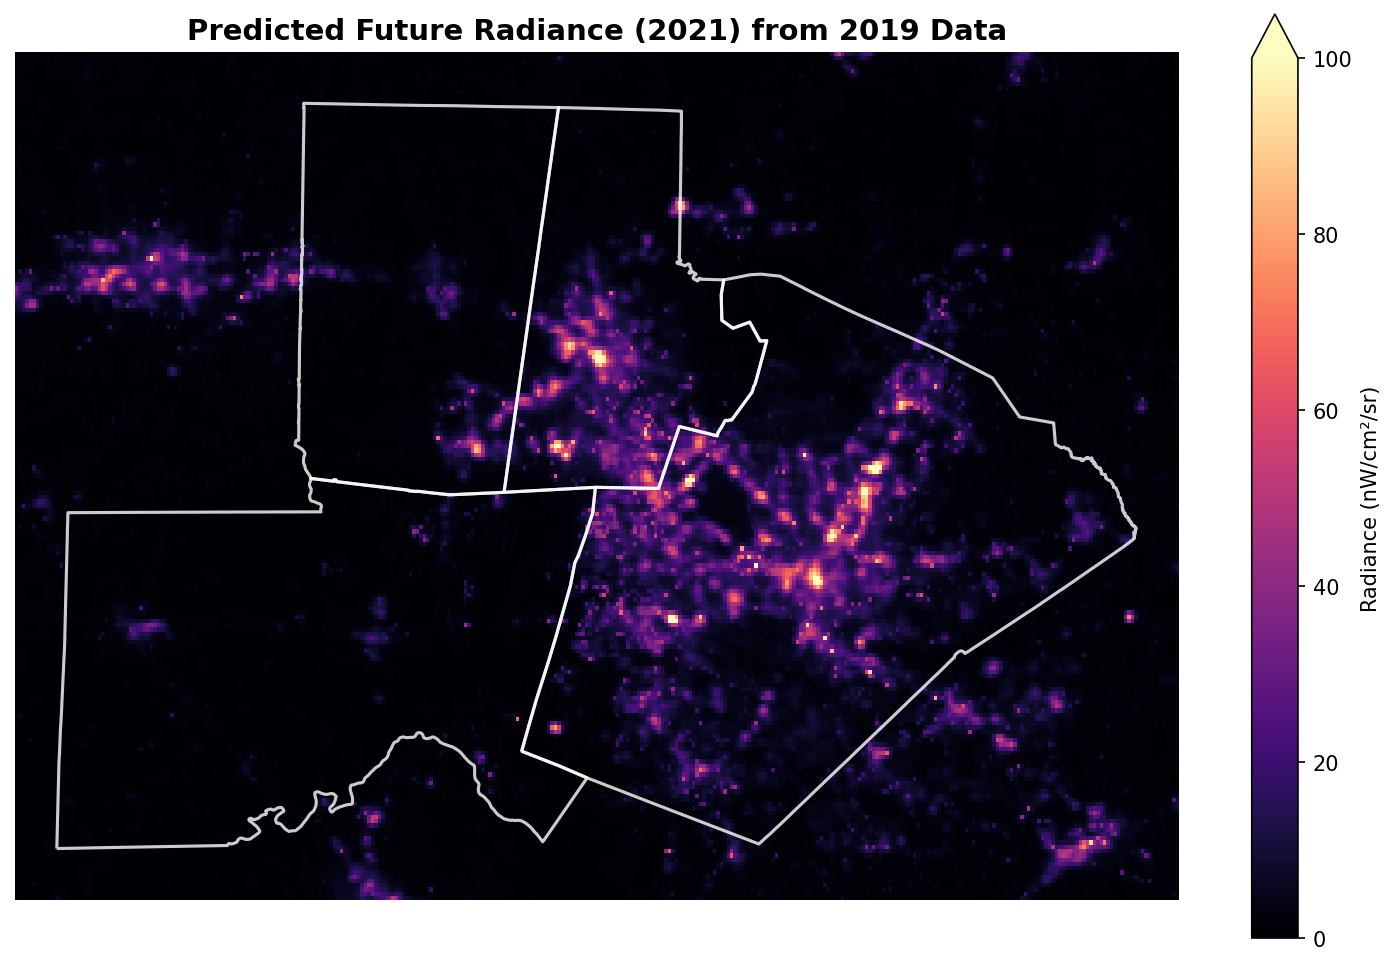

In [3]:
counties_path = config.COUNTIES_SHP # e.g. "data/tl_2024_us_county.shp"
inferred_radiance_2021 = rioxarray.open_rasterio('data/inferred_radiance_2021_from2019_lowthresh.tif')

# 1. Plot Future Radiance (0 to 100)
plot_nc_urban_core(
    inferred_radiance_2021, 
    counties_path, 
    title="Predicted Future Radiance (2021) from 2019 Data", 
    vmin=0, 
    vmax=100, 
    cmap='magma'
)

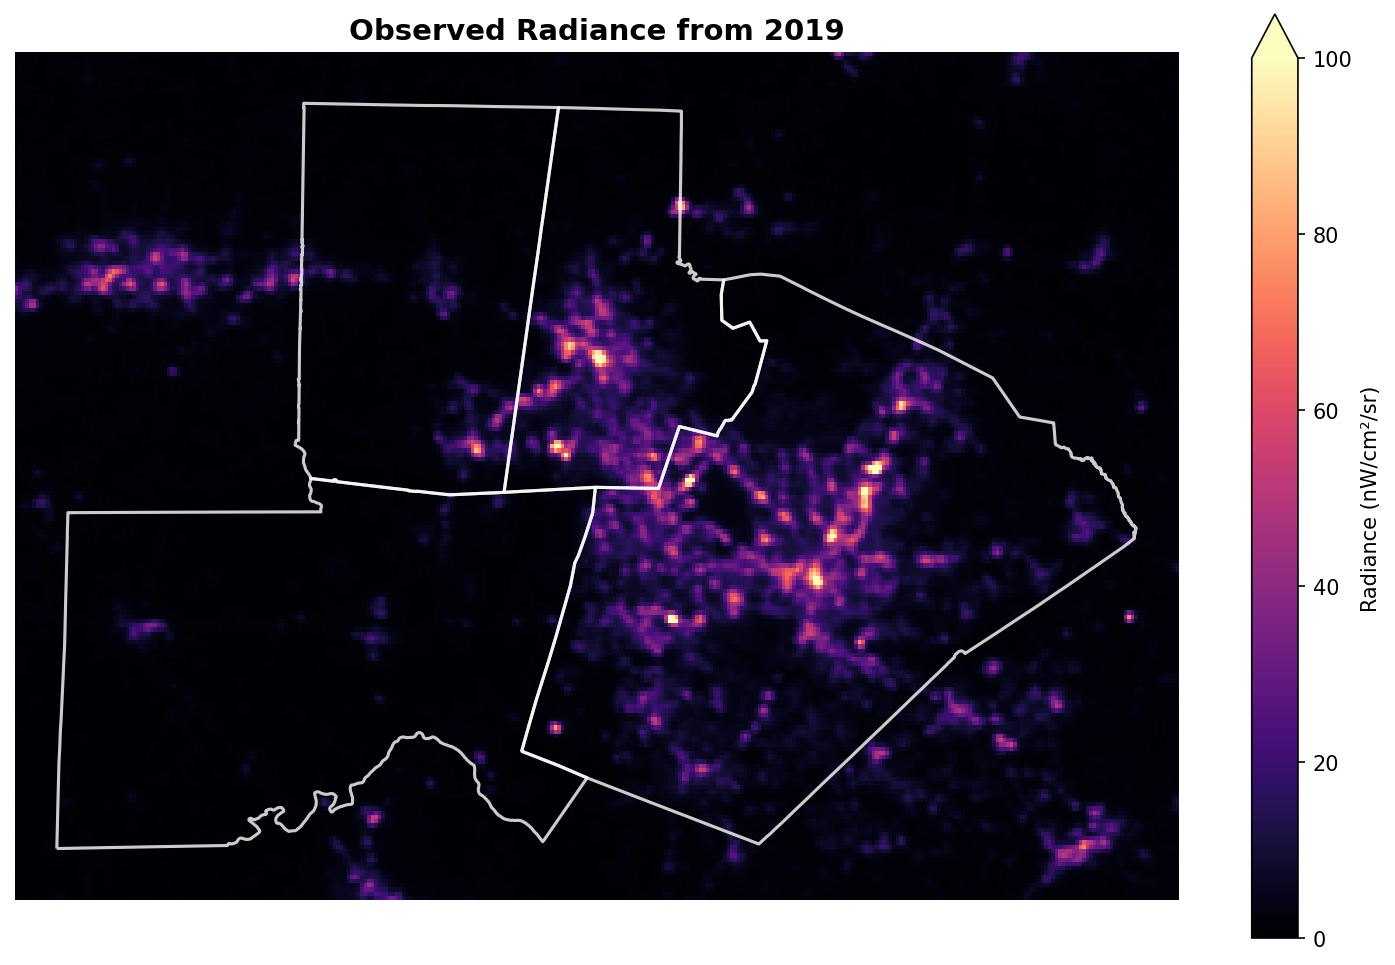

In [7]:
viirs_older_path = config.RADIANCE_OLDER
nc_urban_core_extent = {
    'minx': -79.605,
    'miny': 35.46,
    'maxx': -78.2,
    'maxy': 36.29
}
viirs_older = rioxarray.open_rasterio(viirs_older_path).squeeze()
#clip to urban core
viirs_older = viirs_older.rio.clip_box(**nc_urban_core_extent)
plot_nc_urban_core(
    viirs_older, 
    counties_path, 
    title=f"Observed Radiance from {older_year}", 
    vmin=0, 
    vmax=100, 
    cmap='magma'
)

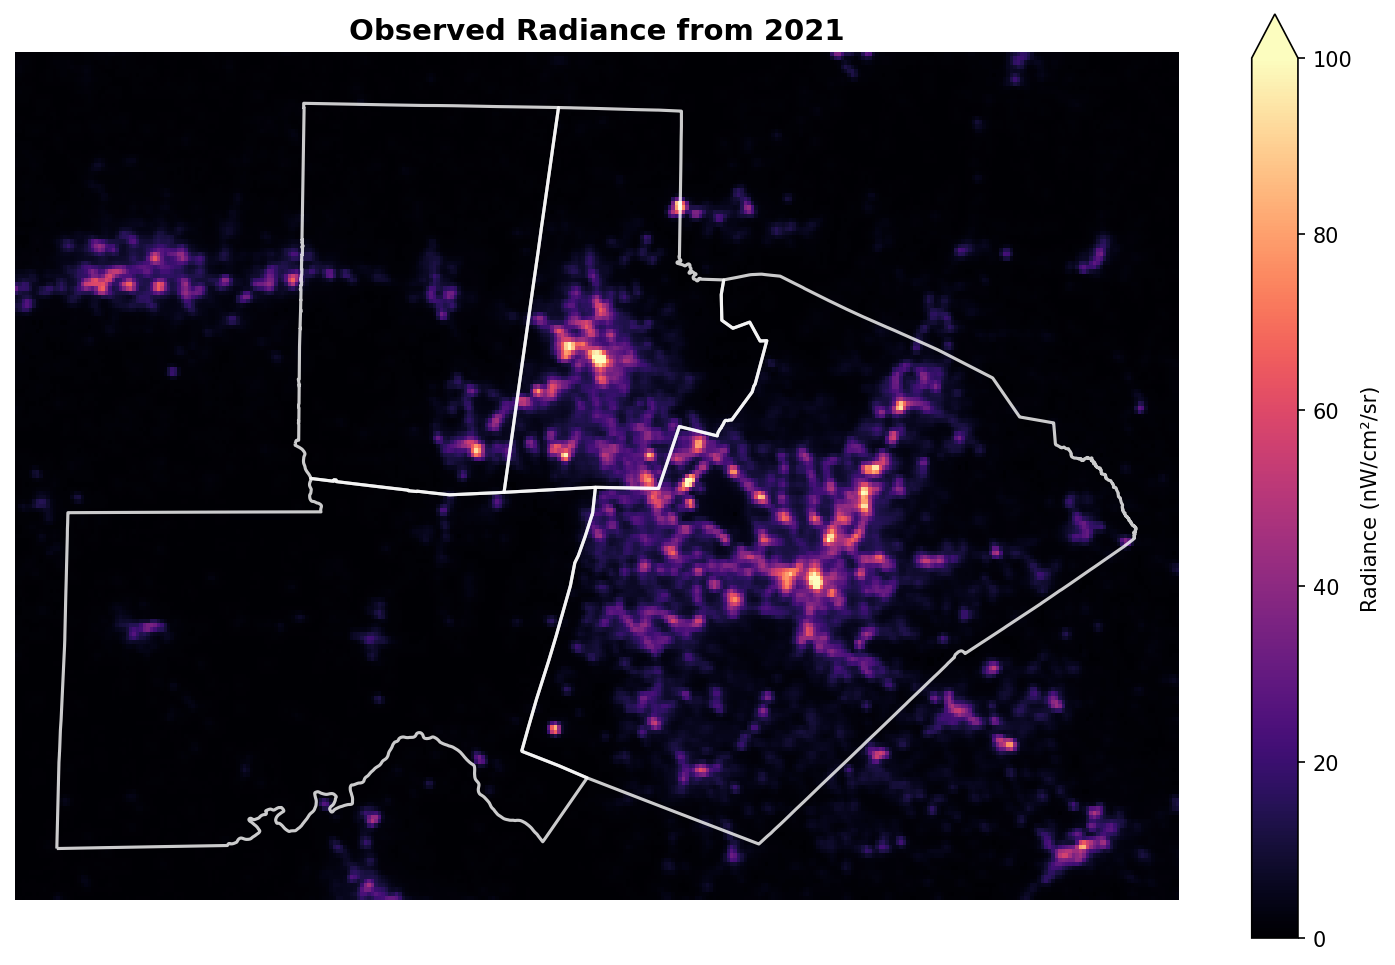

In [5]:
viirs_newer = rioxarray.open_rasterio(config.RADIANCE_NEWER).squeeze()
#clip to urban core
viirs_newer = viirs_newer.rio.clip_box(**nc_urban_core_extent)
plot_nc_urban_core(
    viirs_newer, 
    counties_path, 
    title=f"Observed Radiance from {newer_year}", 
    vmin=0, 
    vmax=100, 
    cmap='magma'
)

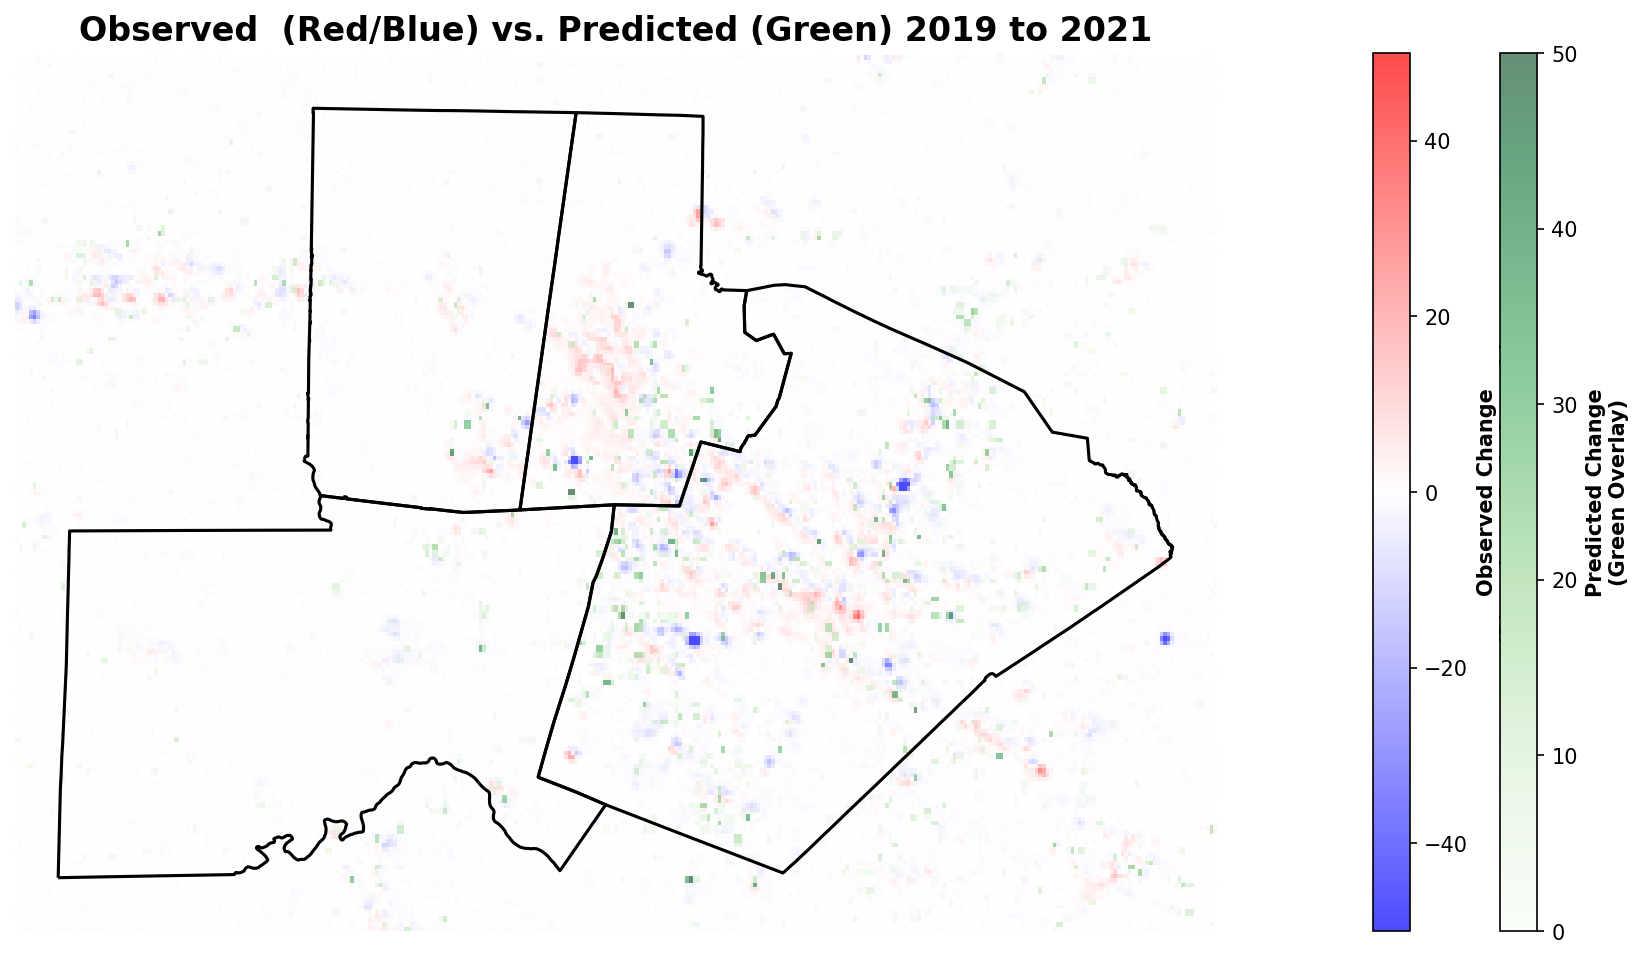

In [6]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
viirs_newer_matched = viirs_newer.rio.reproject_match(viirs_older)
observed_change = viirs_newer_matched - viirs_older
predicted_change = inferred_radiance_2021 - viirs_older
# 1. Setup Clipping (Same as before)
# ---------------------------------------------------------
counties = gpd.read_file(counties_path)
target_names = ['Wake', 'Durham', 'Orange', 'Chatham']
roi_gdf = counties[
    (counties['NAME'].isin(target_names)) & 
    (counties['STATEFP'] == '37') 
]
roi_gdf = roi_gdf.to_crs(observed_change.rio.crs)

# Get Bounds
minx, miny, maxx, maxy = roi_gdf.total_bounds
buffer = 0.05
minx, miny, maxx, maxy = minx-buffer, miny-buffer, maxx+buffer, maxy+buffer

# Clip Both
obs_clip = observed_change.rio.clip_box(minx, miny, maxx, maxy)
pred_clip = predicted_change.rio.clip_box(minx, miny, maxx, maxy)

# 2. Mask the Predicted Layer
# ---------------------------------------------------------
# We only want to plot the green overlay where the model actually predicts change.
# We set values < 1.0 (negligible change) to NaN, which Matplotlib renders as transparent.
pred_masked = pred_clip.where(pred_clip > 1.0)

# 3. Create Overlay Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10), dpi=150)

# A. Bottom Layer: Observed Change (Blue = Loss, Red = Growth)
# We make this slightly washed out (alpha=0.7) so the overlay pops
obs_im = obs_clip.plot(
    ax=ax,
    cmap='bwr',
    vmin=-50, vmax=50,
    add_colorbar=False, # We'll add custom legend later
    alpha=0.7
)

# B. Top Layer: Predicted Change (Green)
# Only shows where model predicts > 1 unit of growth
pred_im = pred_masked.plot(
    ax=ax,
    cmap='Greens',
    vmin=0, vmax=50,
    add_colorbar=False,
    alpha=0.6 # Semi-transparent so you can see the Red/Blue underneath
)

# C. Outlines
roi_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=1.5)

# 4. Custom Formatting & Colorbars
# ---------------------------------------------------------
ax.set_title(f"Observed  (Red/Blue) vs. Predicted (Green) {older_year} to {newer_year}", fontsize=16, fontweight='bold')
ax.set_axis_off()

# Add Colorbars manually to the right, smaller size
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
cax_obs = divider.append_axes("right", size="2.5%", pad=0.1)
cax_pred = divider.append_axes("right", size="2.5%", pad=0.6)

cbar_obs = plt.colorbar(obs_im, cax=cax_obs, orientation='vertical')
cbar_obs.set_label('Observed Change\n(Blue=Loss, Red=Growth)', fontweight='bold')

cbar_pred = plt.colorbar(pred_im, cax=cax_pred, orientation='vertical')
cbar_pred.set_label('Predicted Change\n(Green Overlay)', fontweight='bold')

plt.tight_layout()
plt.show()

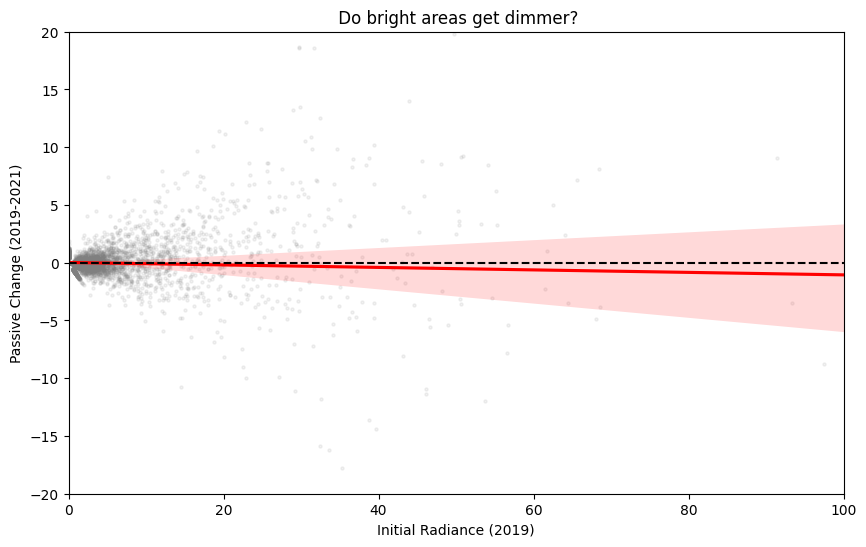

In [42]:
import seaborn as sns
import numpy as np
import rasterio as rio
from rasterio.enums import Resampling
# 1. Isolate "Stable" Pixels (No Impervious Change)
# We use a small threshold (e.g., < 1% change) to find stable areas
impervious_older = rioxarray.open_rasterio(config.IMPERV_OLDER).squeeze()
impervious_newer = rioxarray.open_rasterio(config.IMPERV_NEWER).squeeze()

#clip to urban core
impervious_older = impervious_older.rio.clip_box(**nc_urban_core_extent, crs =viirs_older.rio.crs)
impervious_newer = impervious_newer.rio.clip_box(**nc_urban_core_extent, crs =viirs_older.rio.crs)
#rescale
impervious_older = impervious_older.rio.reproject_match(
        viirs_newer,
        resampling=Resampling.average)
impervious_newer = impervious_newer.rio.reproject_match(
        viirs_newer,
        resampling=Resampling.average)  
#clip
imperv_change = impervious_newer - impervious_older
stable_mask = (np.abs(imperv_change) < 1.0) 

# 2. Extract Data for these pixels
# We'll take a random sample of 10,000 points to keep plotting fast
# We need 2019 radiance (X) and The Change (Y)
stable_pixels_x = viirs_older.where(stable_mask).values.ravel()
stable_pixels_y = observed_change.where(stable_mask).values.ravel()

# Filter NaNs
mask_valid = np.isfinite(stable_pixels_x) & np.isfinite(stable_pixels_y)
sample_indices = np.random.choice(np.where(mask_valid)[0], 10000, replace=False)

x_sample = stable_pixels_x[sample_indices]
y_sample = stable_pixels_y[sample_indices]

# 3. Plot "The Convergence"
plt.figure(figsize=(10, 6))
sns.regplot(
    x=x_sample, 
    y=y_sample, 
    scatter_kws={'alpha': 0.1, 's': 5, 'color': 'gray'},
    line_kws={'color': 'red'}
)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Initial Radiance (2019)")
plt.ylabel("Passive Change (2019-2021)")
plt.title(" Do bright areas get dimmer?")
plt.ylim(-20, 20)
plt.xlim(0, 100)
plt.show()

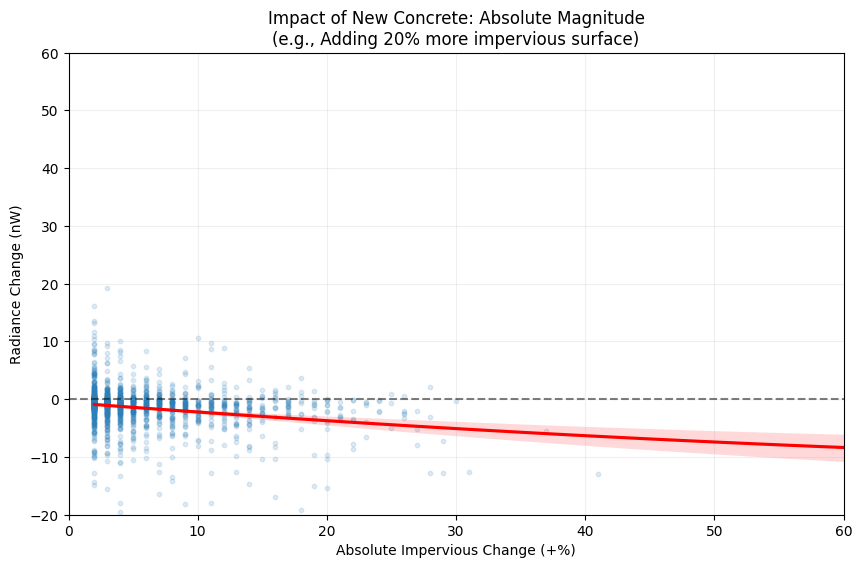

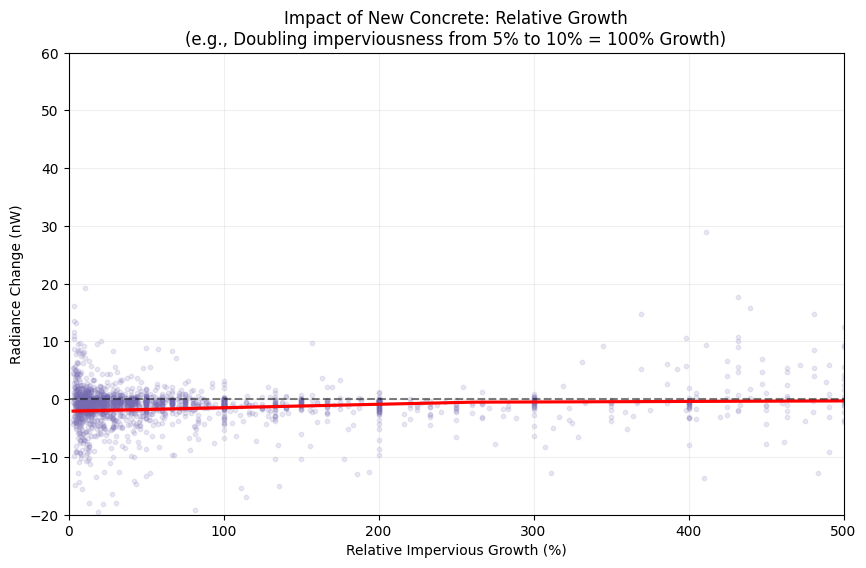

In [16]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import rioxarray
from rasterio.enums import Resampling
import config

# =========================================================
# 1. PREPARE DATA
# =========================================================

# Load and Clip Impervious Data
impervious_older = rioxarray.open_rasterio(config.IMPERV_OLDER).squeeze()
impervious_newer = rioxarray.open_rasterio(config.IMPERV_NEWER).squeeze()

# Clip to urban core extent
impervious_older = impervious_older.rio.clip_box(**nc_urban_core_extent, crs=viirs_older.rio.crs)
impervious_newer = impervious_newer.rio.clip_box(**nc_urban_core_extent, crs=viirs_older.rio.crs)

# Rescale to match VIIRS (700m grid)
impervious_older = impervious_older.rio.reproject_match(viirs_newer, resampling=Resampling.average)
impervious_newer = impervious_newer.rio.reproject_match(viirs_newer, resampling=Resampling.average)

# Calculate Deltas
imp_change_absolute = impervious_newer - impervious_older

obs_rad_change = viirs_newer - viirs_older

# =========================================================
# 2. FILTER & SAMPLE
# =========================================================

# Define "Development Mask": Only look at pixels where imperviousness INCREASED by at least 1%
# We ignore stable areas and demolition (negative change)
dev_mask = (imp_change_absolute > 1.0)

# Extract flattened arrays for sampling
x_imp_abs = imp_change_absolute.where(dev_mask).values.ravel()
x_imp_old = impervious_older.where(dev_mask).values.ravel()
y_rad_change = obs_rad_change.where(dev_mask).values.ravel()

# Filter NaNs
valid_idx = np.isfinite(x_imp_abs) & np.isfinite(y_rad_change) & (x_imp_old > 0.5) # Avoid divide-by-zero later
indices = np.where(valid_idx)[0]

# Sample 10,000 points for performance
if len(indices) > 10000:
    sample_idx = np.random.choice(indices, 10000, replace=False)
else:
    sample_idx = indices

# Create Sample Vectors
samp_abs_change = x_imp_abs[sample_idx]  # The +5% to +50% value
samp_old_val = x_imp_old[sample_idx]     # The starting value (e.g. 5%)
samp_rad_change = y_rad_change[sample_idx]

# Calculate Relative Growth: (New - Old) / Old
# e.g., Going from 5% to 10% is a 1.0 (100%) increase
samp_rel_change = (samp_abs_change / samp_old_val) * 100

# =========================================================
# 3. PLOT FIGURE 1: ABSOLUTE CHANGE
# =========================================================
plt.figure(figsize=(10, 6))
sns.regplot(
    x=samp_abs_change, 
    y=samp_rad_change, 
    scatter_kws={'alpha': 0.15, 's': 10, 'color': '#2c7fb8'}, # Blueish
    line_kws={'color': 'red'},
    order=2 # Polynomial fit often captures saturation better
)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel("Absolute Impervious Change (+%)")
plt.ylabel("Radiance Change (nW)")
plt.title("Impact of New Concrete: Absolute Magnitude\n(e.g., Adding 20% more impervious surface)")
plt.xlim(0, 60) # Limit x-axis to reasonable growth
plt.ylim(-20, 60)
plt.grid(True, alpha=0.2)
plt.show()

# =========================================================
# 4. PLOT FIGURE 2: RELATIVE GROWTH (The "100x" View)
# =========================================================
plt.figure(figsize=(10, 6))
sns.regplot(
    x=samp_rel_change, 
    y=samp_rad_change, 
    scatter_kws={'alpha': 0.15, 's': 10, 'color': '#756bb1'}, # Purplish
    line_kws={'color': 'red'},
    logx=True # Use log-x scale because relative growth can be huge (1000%+)
)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel("Relative Impervious Growth (%)")
plt.ylabel("Radiance Change (nW)")
plt.title("Impact of New Concrete: Relative Growth\n(e.g., Doubling imperviousness from 5% to 10% = 100% Growth)")

# Set nice log-like ticks for readability if limiting to standard range
plt.xlim(0, 500) # Look at 0% to 500% growth
plt.ylim(-20, 60)
plt.grid(True, alpha=0.2)
plt.show()

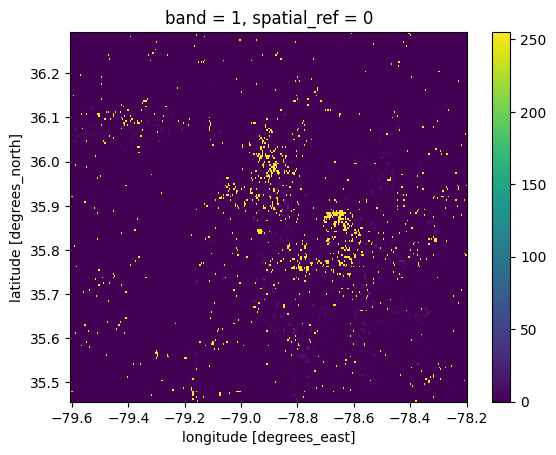

In [19]:
imp_change_absolute.plot()

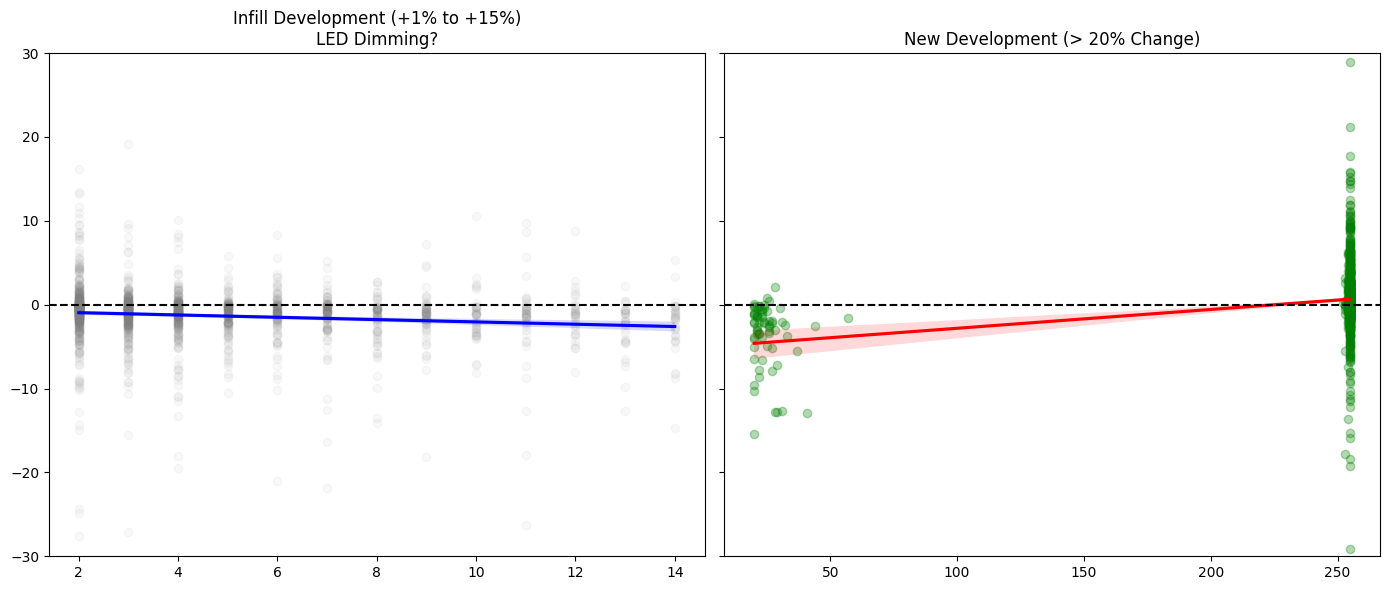

In [11]:
# Create masks for two types of development
# 1. Infill: Small changes (likely inside existing, dimming cities)
mask_infill = (x_imp_abs > 1.0) & (x_imp_abs < 15.0)

# 2. Greenfield: Huge changes (New subdivisions, likely turning on NEW lights)
mask_greenfield = (x_imp_abs >= 20.0)

# Extract
x_infill = x_imp_abs[mask_infill]
y_infill = y_rad_change[mask_infill]

x_green = x_imp_abs[mask_greenfield]
y_green = y_rad_change[mask_greenfield]

# Plot Comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot A: Infill (Expect Negative/Flat trend due to Shielding)
sns.regplot(x=x_infill, y=y_infill, ax=ax[0], 
            scatter_kws={'alpha':0.05, 'color':'gray'}, line_kws={'color':'blue'})
ax[0].set_title("Infill Development (+1% to +15%)\nLED Dimming?")
ax[0].axhline(0, color='black', linestyle='--')
ax[0].set_ylim(-30, 30)

# Plot B: Greenfield (Expect Positive trend)
sns.regplot(x=x_green, y=y_green, ax=ax[1], 
            scatter_kws={'alpha':0.3, 'color':'green'}, line_kws={'color':'red'})
ax[1].set_title("New Development (> 20% Change)")
ax[1].axhline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

Total Greenfield Pixels Found: 1229
Min Change: 20.00%, Max Change: 255.00%


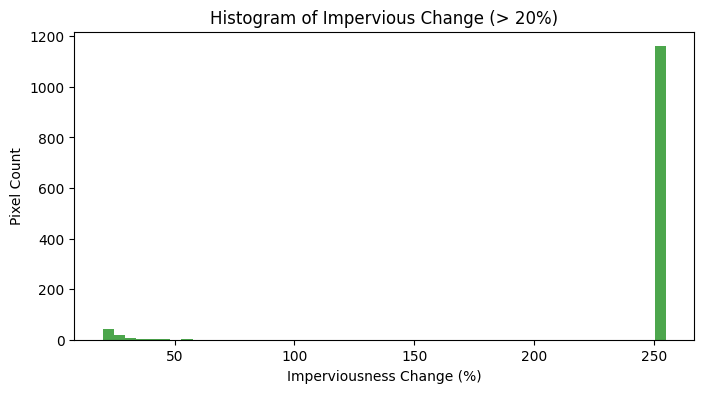

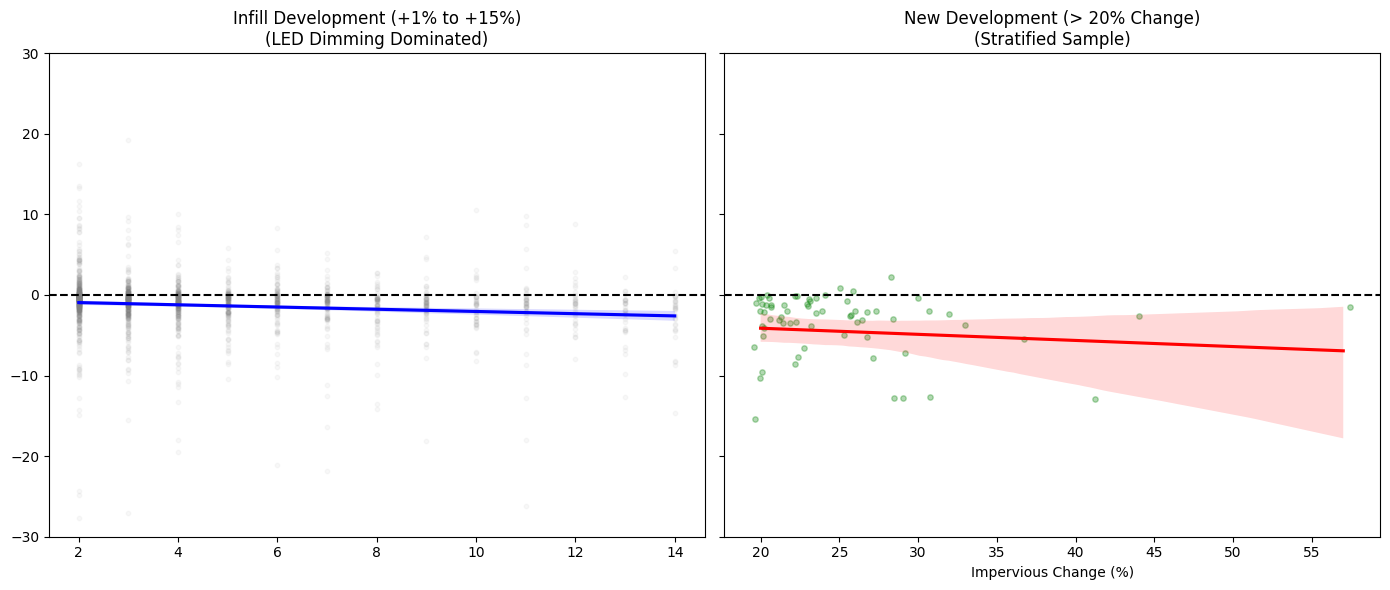

In [15]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# =========================================================
# 1. DIAGNOSTIC: Check Distribution
# =========================================================
# Get all "Greenfield" pixels (> 20% change)
# We use flattened arrays from previous steps
mask_green = (x_imp_abs >= 20.0)
green_changes = x_imp_abs[mask_green]

print(f"Total Greenfield Pixels Found: {len(green_changes)}")
print(f"Min Change: {green_changes.min():.2f}%, Max Change: {green_changes.max():.2f}%")

# Plot Histogram to see if it's truly "clumped" or just a sampling artifact
plt.figure(figsize=(8, 4))
plt.hist(green_changes, bins=50, color='green', alpha=0.7)
plt.title("Histogram of Impervious Change (> 20%)")
plt.xlabel("Imperviousness Change (%)")
plt.ylabel("Pixel Count")
plt.show()

# =========================================================
# 2. STRATIFIED SAMPLING (The Fix)
# =========================================================
# If the histogram shows data exists across the range, we force the sample
# to pick points from everywhere, not just the "clump".

# Break into bins (20-40, 40-60, 60-80, 80-100)
# We take up to 2,000 points from each bin to ensure coverage
bins = [20, 40, 60, 80, 101]
final_indices = []

df_green = pd.DataFrame({'change': x_imp_abs, 'rad': y_rad_change})
# Filter global frame to just greenfield
df_green = df_green[df_green['change'] >= 20.0]

for i in range(len(bins)-1):
    low, high = bins[i], bins[i+1]
    # Find points in this bin
    subset = df_green[(df_green['change'] >= low) & (df_green['change'] < high)]
    
    # Sample up to 2000
    n_sample = min(len(subset), 2000)
    if n_sample > 0:
        sampled = subset.sample(n_sample, replace=False)
        final_indices.extend(sampled.index.tolist())

# Extract the balanced sample
x_green_balanced = df_green.loc[final_indices, 'change'].values
y_green_balanced = df_green.loc[final_indices, 'rad'].values

# =========================================================
# 3. PLOT WITH JITTER
# =========================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot A: Infill (Unchanged)
sns.regplot(x=x_infill, y=y_infill, ax=ax[0], 
            scatter_kws={'alpha':0.05, 'color':'gray', 's':10}, 
            line_kws={'color':'blue'})
ax[0].set_title("Infill Development (+1% to +15%)\n(LED Dimming Dominated)")
ax[0].axhline(0, color='black', linestyle='--')
ax[0].set_ylim(-30, 30)

# Plot B: Greenfield (Balanced & Jittered)
# x_jitter adds fake noise ONLY for plotting, to un-clump the visual
sns.regplot(x=x_green_balanced, y=y_green_balanced, ax=ax[1], 
            x_jitter=0.5, # <--- Adds visual spread to integer columns
            scatter_kws={'alpha':0.3, 'color':'green', 's':15}, 
            line_kws={'color':'red'})

ax[1].set_title("New Development (> 20% Change)\n(Stratified Sample)")
ax[1].set_xlabel("Impervious Change (%)")
ax[1].axhline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

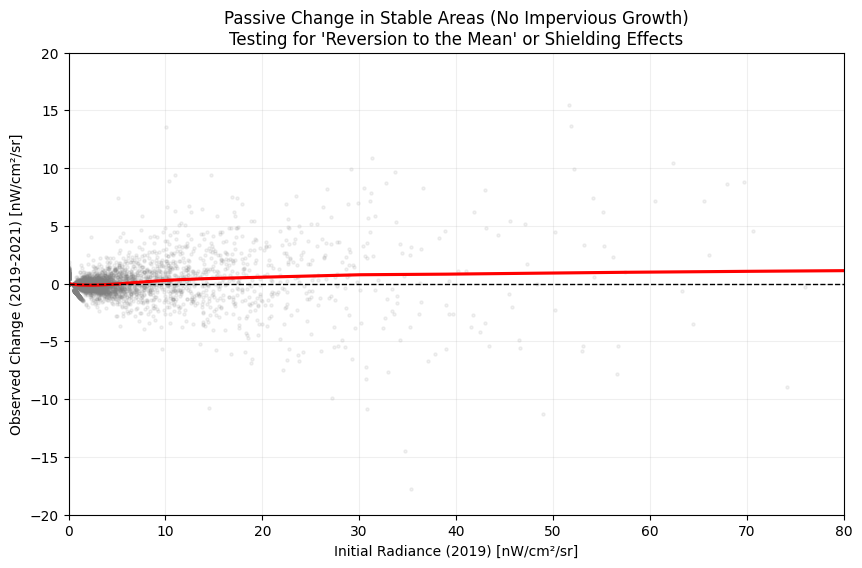

In [40]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. DEFINE STABLE PIXELS (No Development)
# =========================================================
# We look for pixels where the absolute change is negligible (< 1%)
stable_mask = (np.abs(imp_change_absolute) < 1.0)

# Extract flattened arrays
x_initial_rad = viirs_older.where(stable_mask).values.ravel()
y_rad_change = obs_rad_change.where(stable_mask).values.ravel()

# Filter NaNs and outliers (e.g. extremely bright pixels > 150)
# We limit initial radiance to < 150 to keep the plot readable (avoids airport/stadium outliers)
valid_idx = np.isfinite(x_initial_rad) & np.isfinite(y_rad_change) & (x_initial_rad < 150)
indices = np.where(valid_idx)[0]

# Sample 10,000 points for performance
if len(indices) > 10000:
    sample_idx = np.random.choice(indices, 10000, replace=False)
else:
    sample_idx = indices

samp_initial = x_initial_rad[sample_idx]
samp_change = y_rad_change[sample_idx]

# =========================================================
# 2. PLOT: PASSIVE CHANGE
# =========================================================
plt.figure(figsize=(10, 6))

# Main Scatter Plot
sns.regplot(
    x=samp_initial, 
    y=samp_change, 
    scatter_kws={'alpha': 0.1, 's': 5, 'color': 'gray'},
    line_kws={'color': 'red'},
    lowess=True # Uses a locally weighted regression line to capture non-linear trends
)

# Reference Lines
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Formatting
plt.xlabel("Initial Radiance (2019) [nW/cm²/sr]")
plt.ylabel("Observed Change (2019-2021) [nW/cm²/sr]")
plt.title("Passive Change in Stable Areas (No Impervious Growth)\nTesting for 'Reversion to the Mean' or Shielding Effects")

# Set limits to focus on the bulk of the data
plt.xlim(0, 80)
plt.ylim(-20, 20)
plt.grid(True, alpha=0.2)

plt.show()

In [24]:
import geopandas as gpd
from geocube.api.core import make_geocube
from scipy.ndimage import distance_transform_edt
import numpy as np
import rioxarray
from shapely.geometry import box
# 1. Load Primary Roads (National File)
# ---------------------------------------------------------
roads_path = "data/shapefiles/primaryroads/tl_2024_us_primaryroads.shp"
roads_gdf = gpd.read_file(roads_path)

# 2. Clip to Study Area (Crucial Optimization)
# ---------------------------------------------------------
# Don't rasterize the whole US. Just clip to your NC/VA extent.
# We use the bounds of your existing 'viirs_da' (the clipped version from previous steps)
# OR if nc_urban_core_extent is a dict {'minx':..., 'miny':...}
study_bbox = box(**nc_urban_core_extent)

# 2. Put that Polygon into the GeoSeries
study_box_proj = gpd.GeoSeries(
    [study_bbox],           # Note the brackets: expects a list of geometries
    crs=viirs_older.rio.crs # Define the starting CRS (probably EPSG:4326 or VIIRS projection)
).to_crs(roads_gdf.crs)

# Transform study box to Roads CRS to do the vector clip
roads_clipped = roads_gdf.clip(study_box_proj)
roads_clipped['presence'] = 1  # Dummy variable for rasterization

# 3. Rasterize Roads (Boolean Mask)
# ---------------------------------------------------------
# Create a binary raster: 1 = Primary Road, NaN = Background
road_raster = make_geocube(
    vector_data=roads_clipped,
    measurements=["presence"], # Dummy variable, we just need presence
    like=viirs_newer,             # Match VIIRS grid exactly
    fill=0                     # 0 = No Road
)

# Convert to boolean (1 where road exists, 0 elsewhere)
road_mask = (road_raster['presence'] > 0).values

# 4. Calculate Distance Transform
# ---------------------------------------------------------
# distance_transform_edt calculates distance to the nearest "0" pixel.
# So we INVERT the mask: We want distance to the nearest "1" (Road).
# input: 0 = Target (Road), 1 = Background
inverted_mask = ~road_mask 

# Calculate distance in *pixels*
dist_pixels = distance_transform_edt(inverted_mask)

# Convert to Kilometers (Approximate)
# VIIRS pixels are ~500m (0.5km)
# (For precise science, project to UTM first, but this is fine for regression)
dist_km = dist_pixels * 0.5 

# 5. Save/Use as DataArray
dist_da = viirs_newer.copy(data=dist_km)
#dist_da.name = "dist_primary_km"

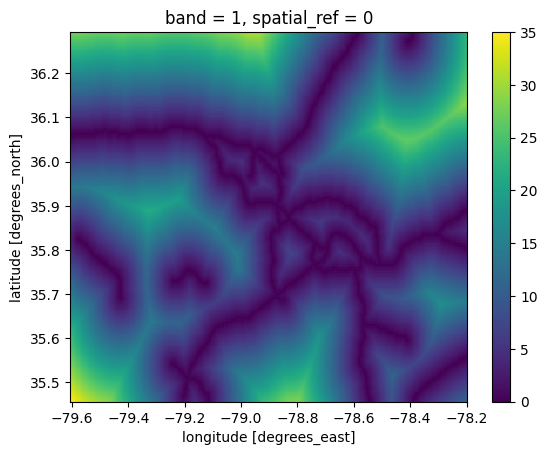

In [26]:
dist_da.plot()

In [31]:
import pandas as pd
# Create a DataFrame for regression
df_stable = pd.DataFrame({
    'change': observed_change.values.ravel(),
    'initial_rad': viirs_older.values.ravel(),
    'dist_km': dist_da.values.ravel()
})
stable_imperv_mask = impervious_newer - impervious_older
stable_imperv_mask = (np.abs(stable_imperv_mask) < 10)
# Filter: Stable Imperviousness & Finite Data
mask = (stable_imperv_mask.ravel()) & (np.isfinite(df_stable['change']))
df_reg = df_stable[mask].sample(10000) # Sample for speed

# Train Model
import bambi as bmb
model = bmb.Model("change ~ initial_rad + dist_km", df_reg)
results = model.fit()

AttributeError: 'DataArray' object has no attribute 'ravel'

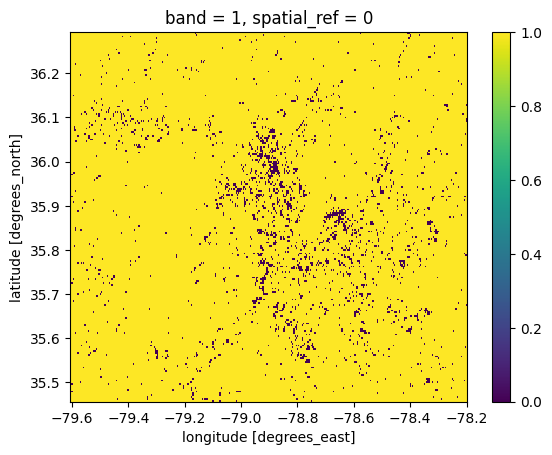

In [32]:
stable_imperv_mask .plot()

In [14]:
nc_urban_core_extent

{'minx': -79.605, 'miny': 35.46, 'maxx': -78.2, 'maxy': 36.29}

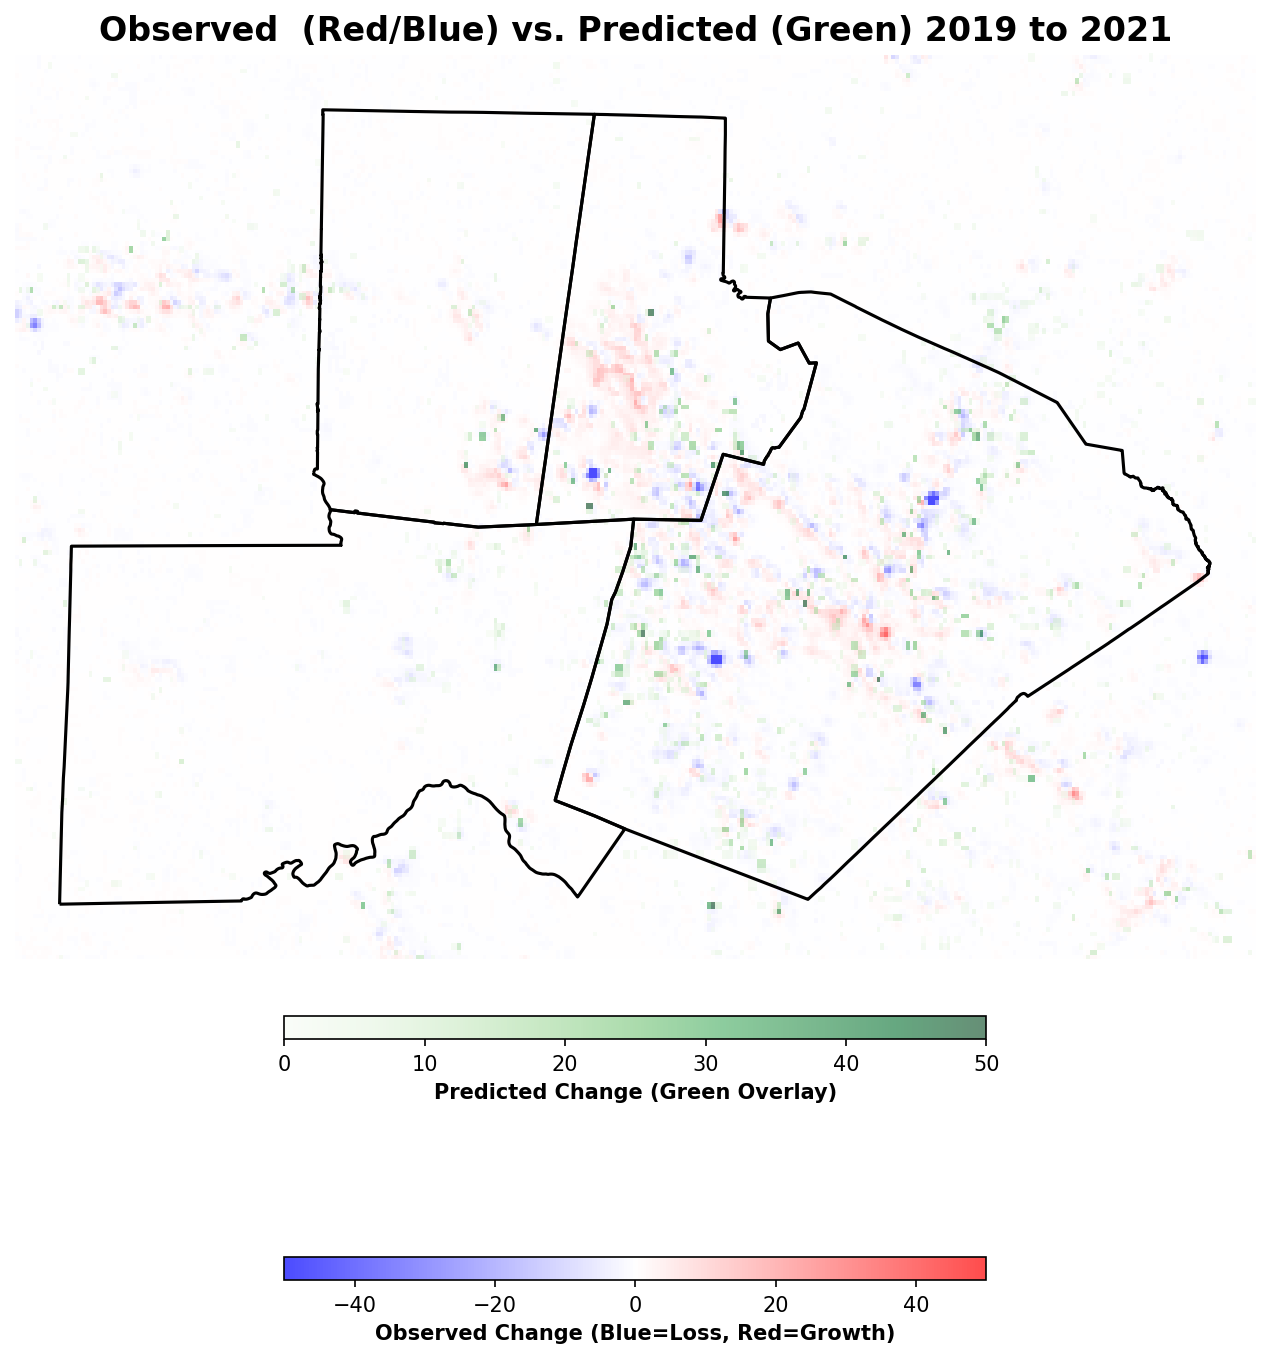

In [38]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

# 1. Setup Clipping (Same as before)
# ---------------------------------------------------------
counties = gpd.read_file(counties_path)
target_names = ['Wake', 'Durham', 'Orange', 'Chatham']
roi_gdf = counties[
    (counties['NAME'].isin(target_names)) & 
    (counties['STATEFP'] == '37') 
]
roi_gdf = roi_gdf.to_crs(observed_change.rio.crs)

# Get Bounds
minx, miny, maxx, maxy = roi_gdf.total_bounds
buffer = 0.05
minx, miny, maxx, maxy = minx-buffer, miny-buffer, maxx+buffer, maxy+buffer

# Clip Both
obs_clip = observed_change.rio.clip_box(minx, miny, maxx, maxy)
pred_clip = predicted_change.rio.clip_box(minx, miny, maxx, maxy)

# 2. Mask the Predicted Layer
# ---------------------------------------------------------
# We only want to plot the green overlay where the model actually predicts change.
# We set values < 1.0 (negligible change) to NaN, which Matplotlib renders as transparent.
pred_masked = pred_clip.where(pred_clip > 1.0)

# 3. Create Overlay Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10), dpi=150)

# A. Bottom Layer: Observed Change (Blue = Loss, Red = Growth)
# We make this slightly washed out (alpha=0.7) so the overlay pops
obs_im = obs_clip.plot(
    ax=ax,
    cmap='bwr',
    vmin=-50, vmax=50,
    add_colorbar=False, # We'll add custom legend later
    alpha=0.7
)

# B. Top Layer: Predicted Change (Green)
# Only shows where model predicts > 1 unit of growth
pred_im = pred_masked.plot(
    ax=ax,
    cmap='Greens',
    vmin=0, vmax=50,
    add_colorbar=False,
    alpha=0.6 # Semi-transparent so you can see the Red/Blue underneath
)

# C. Outlines
roi_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=1.5)

# 4. Custom Formatting & Colorbars
# ---------------------------------------------------------
ax.set_title(f"Observed  (Red/Blue) vs. Predicted (Green) {older_year} to {newer_year}", fontsize=16, fontweight='bold')
ax.set_axis_off()

# Add Colorbars manually to control placement
# Observed Colorbar (Bottom Left)
cbar_obs = plt.colorbar(obs_im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.4, aspect=30)
cbar_obs.set_label('Observed Change (Blue=Loss, Red=Growth)', fontweight='bold')

# Predicted Colorbar (Bottom Right)
cbar_pred = plt.colorbar(pred_im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.4, aspect=30)
cbar_pred.set_label('Predicted Change (Green Overlay)', fontweight='bold')

plt.tight_layout()
plt.show()

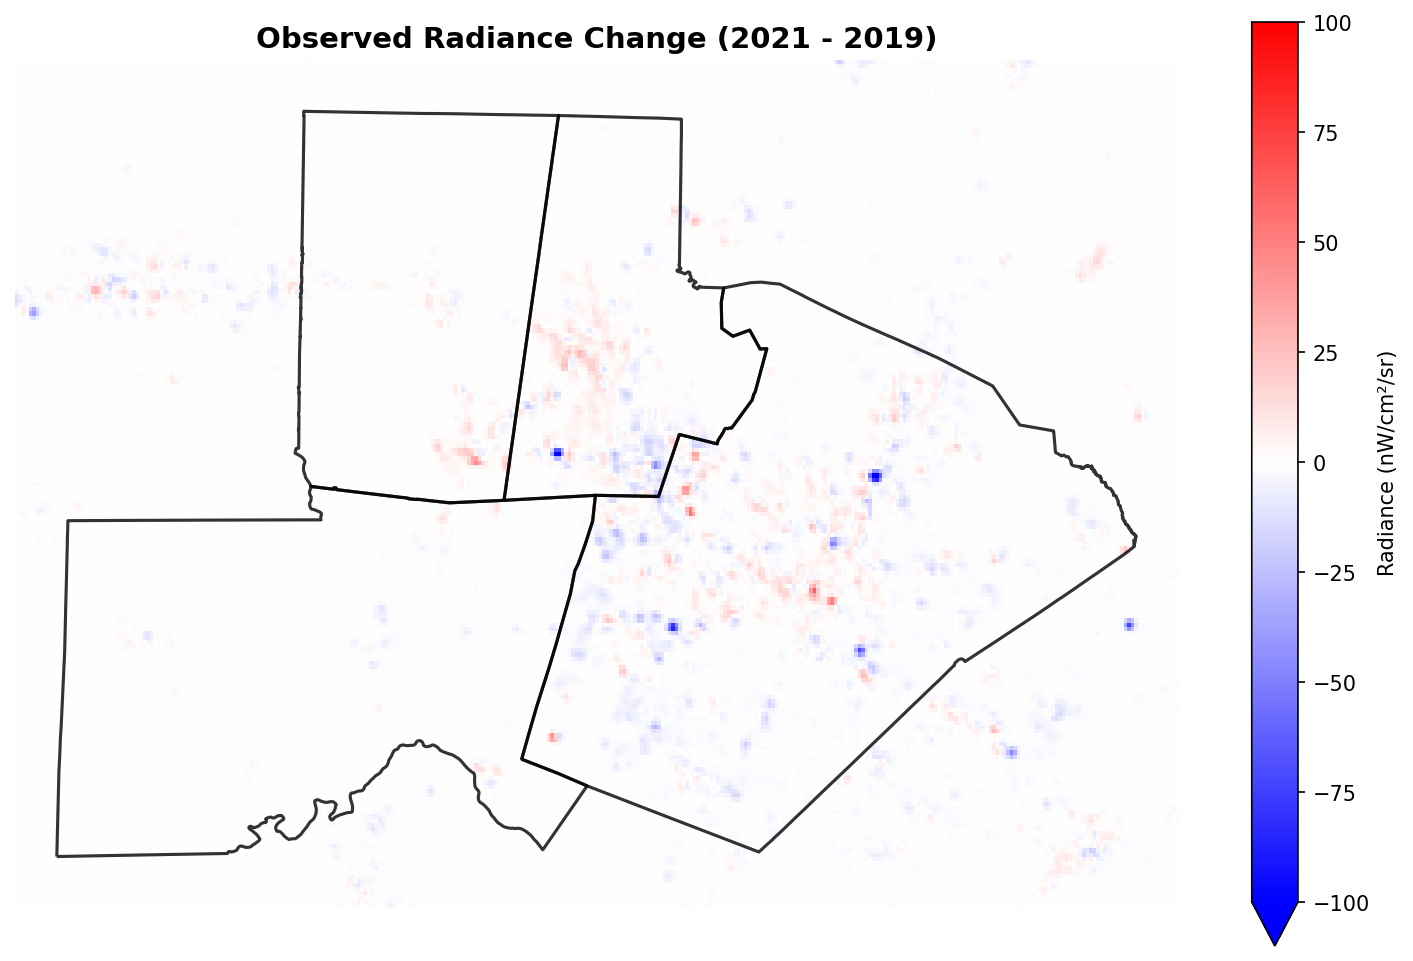

In [ ]:
viirs_newer_matched = viirs_newer.rio.reproject_match(viirs_older)
observed_change = viirs_newer_matched - viirs_older
plot_nc_urban_core(
    observed_change, 
    counties_path, 
    title=f"Observed Radiance Change ({newer_year} - {older_year})", 
    vmin=-100, 
    vmax=100, 
    cmap='bwr',
    outline_color='black'
)

In [ ]:
viirs_newer_matched = viirs_newer.rio.reproject_match(viirs_older)
observed_change = viirs_newer_matched - viirs_older
plot_nc_urban_core(
    observed_change, 
    counties_path, 
    title=f"Observed Radiance Change ({newer_year} - {older_year})", 
    vmin=-100, 
    vmax=100, 
    cmap='bwr',
    outline_color='black'
)

In [23]:
import matplotlib.pyplot as plt
import numpy as np
# Flatten and drop NaNs for both arrays
viirs_older_flat = viirs_older.values.flatten()
viirs_newer_flat = viirs_newer.values.flatten()
viirs_older_flat = viirs_older_flat[~np.isnan(viirs_older_flat)]
viirs_newer_flat = viirs_newer_flat[~np.isnan(viirs_newer_flat)]

plt.figure(figsize=(8, 5))
plt.hist(viirs_older_flat, bins=100, range=(3, 100), color='blue', alpha=0.4, label=f'VIIRS {older_year}')
plt.hist(viirs_newer_flat, bins=100, range=(3, 100), color='red', alpha=0.4, label=f'VIIRS {newer_year}')
plt.xlabel('Radiance')
plt.ylabel('Count')
plt.legend()
plt.title(f'Overlaid Histograms: VIIRS {older_year} vs {newer_year}')
plt.show()

NameError: name 'viirs_older' is not defined

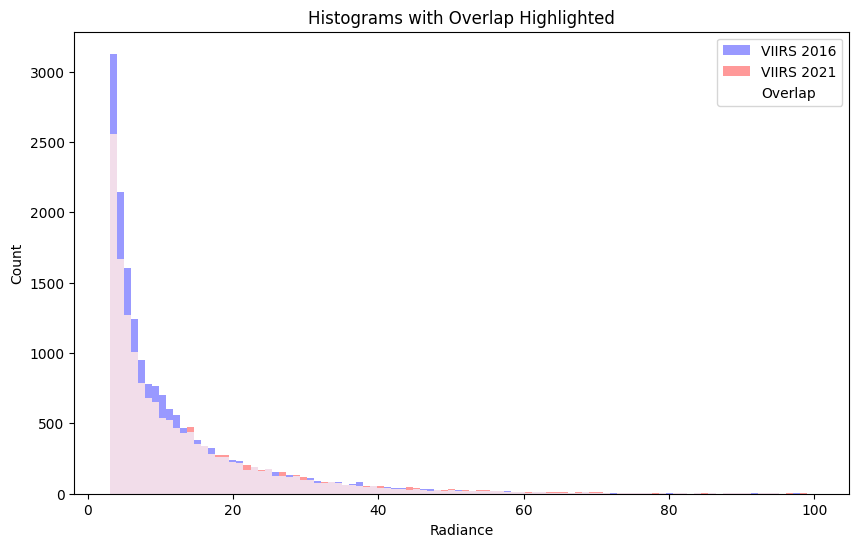

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten and drop NaNs for both arrays
viirs_older_flat = viirs_older.values.flatten()
viirs_newer_flat = viirs_newer.values.flatten()
viirs_older_flat = viirs_older_flat[~np.isnan(viirs_older_flat)]
viirs_newer_flat = viirs_newer_flat[~np.isnan(viirs_newer_flat)]

bins = np.linspace(3, 100, 101)
hist_older, _ = np.histogram(viirs_older_flat, bins=bins)
hist_newer, _ = np.histogram(viirs_newer_flat, bins=bins)
centers = (bins[:-1] + bins[1:]) / 2
width = (bins[1] - bins[0])

plt.figure(figsize=(10, 6))
# Plot older and newer histograms
plt.bar(centers, hist_older, width=width, color='blue', alpha=0.4, label=f'VIIRS {older_year}')
plt.bar(centers, hist_newer, width=width, color='red', alpha=0.4, label=f'VIIRS {newer_year}')

# Calculate overlap and plot in white
overlap = np.minimum(hist_older, hist_newer)
plt.bar(centers, overlap, width=width, color='white', alpha=0.8, label='Overlap')

plt.xlabel('Radiance')
plt.ylabel('Count')
plt.legend()
plt.title(f'Histograms with Overlap Highlighted: {older_year} vs {newer_year}')
plt.show()

In [ ]:
import geopandas as gpd

# 1. Setup Counties Vector & Filter
# ---------------------------------------------------------
full_counties = gpd.read_file(config.COUNTIES_SHP)

# Filter for NC (37) and your specific counties
target_names = ['Wake', 'Durham', 'Orange', 'Chatham']
roi_gdf = full_counties[
    (full_counties['NAME'].isin(target_names)) & 
    (full_counties['STATEFP'] == '37')
]

if roi_gdf.empty:
    raise ValueError("Could not find specified NC counties.")

# Ensure CRS matches the raster (Crucial for alignment)
if roi_gdf.crs != observed_change.rio.crs:
    roi_gdf = roi_gdf.to_crs(observed_change.rio.crs)

# 2. Clip the Raster to the Counties
# ---------------------------------------------------------
# .rio.clip() cuts the raster to the exact polygon boundaries
# invert=False means "keep what is inside the shapes"
urban_core_change = observed_change.rio.clip(
    roi_gdf.geometry,
    roi_gdf.crs,
    drop=True,
    invert=False
)

# 3. Filter Outliers (Remove "No Data" Math Errors)
# ---------------------------------------------------------
# Real urban growth is rarely > 200. Anything higher is likely a sensor glitch.
valid_urban_change = urban_core_change.where(urban_core_change < 500)

# 4. Find Hotspots in the Urban Core
# ---------------------------------------------------------
threshold = -20 # Lower threshold since we are zoomed in
significant_growth = valid_urban_change.where(valid_urban_change < threshold, drop=True)

df_growth = significant_growth.to_dataframe(name='change').dropna().reset_index()
top_hotspots = df_growth.sort_values(by='change', ascending=True).head(10)

# 5. Reproject to Lat/Lon for readability
# ---------------------------------------------------------
gdf_hotspots = gpd.GeoDataFrame(
    top_hotspots,
    geometry=gpd.points_from_xy(top_hotspots.x, top_hotspots.y),
    crs=observed_change.rio.crs 
)
gdf_hotspots_ll = gdf_hotspots.to_crs(epsg=4326)

gdf_hotspots_ll['latitude'] = gdf_hotspots_ll.geometry.y
gdf_hotspots_ll['longitude'] = gdf_hotspots_ll.geometry.x

print(f"Top 10 Areas of reduction (Wake/Durham/Orange/Chatham Only, {older_year} to {newer_year}):")
print(gdf_hotspots_ll[['latitude', 'longitude', 'change']])

Top 10 Areas of reduction (Wake/Durham/Orange/Chatham Only):
     latitude  longitude      change
24  35.887500 -78.566666 -133.865799
23  35.887500 -78.570833 -116.368439
7   35.908333 -78.949999 -106.523621
6   35.908333 -78.954166  -95.955132
56  35.737500 -78.812499  -86.258301
28  35.883333 -78.566666  -83.754013
52  35.741666 -78.812499  -79.161575
27  35.883333 -78.570833  -76.780067
61  35.716666 -78.587499  -70.528236
2   35.912500 -78.954166  -66.649101
